# Study 254 -- WSB-Mentions
## For the curious: does the number of r/WallStreetBets mentions call the meme move?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

In January 2021 a Reddit forum, r/WallStreetBets, lit GameStop on fire. Ever since,
a cottage industry of "mention trackers" promises an edge: **count how often a ticker
is named on WSB this month, then buy the loudest names before they run.**

We hardcode a curated monthly WSB mention-count table for a 14-name meme basket
(GME, AMC, BB, BBBY, KOSS, PLTR, ... -- including names that went to zero), join it to
real Yahoo monthly returns, and ask the only honest question: *does this month's buzz
forecast next month's return?*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wsb_mentions import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

mentions = data.mention_counts()
sig = st.mention_signal(mentions)

if HAVE_REAL:
    prices = data.fetch_meme_monthly(fetch=False, cache_path=CACHE_PATH)
    res = st.half_returns(sig, prices, q=0.50, min_stocks=6)
    spread = res["spread"].dropna()
    hype_x = (res["hype"] - res["basket"]).dropna()
    print(f"Real meme panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res)}  (avg {res['n_total'].mean():.0f} names, {res['n_hype'].mean():.0f} in the loud leg)")
else:
    prices = res = spread = hype_x = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real meme panel loaded: 38 months x 14 tickers
Portfolio months: 36  (avg 13 names, 7 in the loud leg)


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 36, 'n_names': 13, 'n_hype': 7, 'hype_ann': -25.9, 'hype_t': -0.85, 'quiet_ann': -22.4, 'quiet_t': -1.12, 'basket_ann': -23.2, 'spread_ann': -3.5, 'spread_bps': -29.3, 'spread_t': -0.14, 'spread_hit': 0.472, 'spread_sr_lo': -1.105, 'spread_sr_hi': 1.193, 'spread_frac_neg': 0.554, 'hype_xret_ann': -2.7, 'hype_xret_t': -0.2, 'sub_2021_mean': -49.1, 'sub_2021_t': -1.01, 'sub_2021_n': 12, 'sub_2022_mean': 0.8, 'sub_2022_t': 0.04, 'sub_2022_n': 12, 'sub_2023_mean': 37.9, 'sub_2023_t': 0.76, 'sub_2023_n': 12, 'reversal_ann': 3.5, 'reversal_t': 0.14, 'rank_ic': -0.035, 'rank_ic_p': 0.448, 'rank_ic_pairs': 468, 'turnover': 6.8, 'drag_bps': 4.1, 'net_spread_ann': -4.0, 'net_spread_t': -0.15, 'random_excess_bps': -17.4, 'syn_null_t': -0.52, 'syn_pos_t': 14.81, 'syn_rev_t': -16.01}


## The buzz timeline: a spike, a second wave, then a long fade

The mention table encodes the canonical meme-cycle shape: the January-2021 GME/AMC
explosion, the June-2021 AMC second wave, and the slow 2022-2023 cool-off (with
BBBY's final August-2023 pump before bankruptcy).


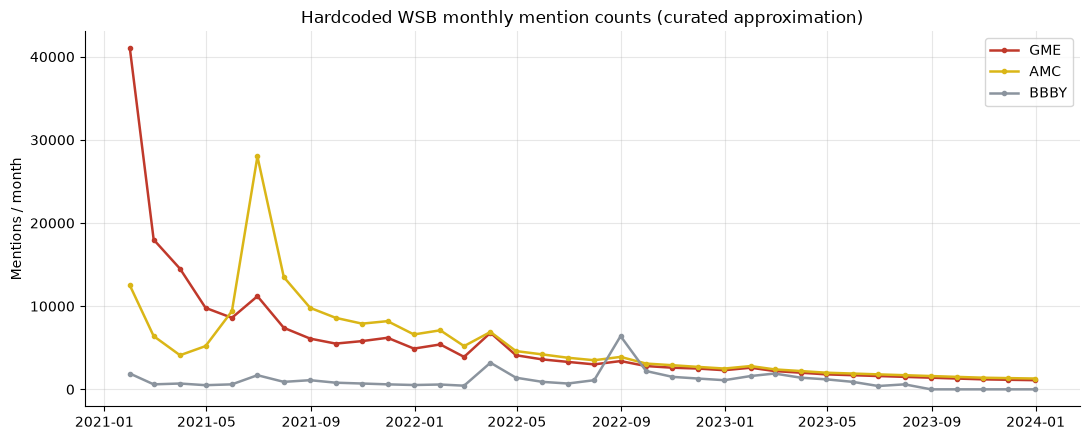

Peak GME buzz: 41000 mentions in 2021-01-31
BBBY's last gasp: 6400 mentions in 2022-08-31


In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for tk, col in [("GME", RED), ("AMC", AMBER), ("BBBY", GREY)]:
    if tk in mentions.columns:
        ax.plot(mentions.index, mentions[tk], lw=1.8, label=tk,
                color=col, marker="o", ms=3)
ax.set_title("Hardcoded WSB monthly mention counts (curated approximation)")
ax.set_ylabel("Mentions / month")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/mentions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Peak GME buzz:", int(mentions['GME'].max()), "mentions in", mentions['GME'].idxmax().date())
print("BBBY's last gasp:", int(mentions['BBBY'].max()), "mentions in", mentions['BBBY'].idxmax().date())


## The strategy in plain words

Every month-end, split the basket in half by mention count: **buy the loud half,
short the quiet half, hold one month, repeat.** If "Reddit knows", the loud half
should beat the quiet half next month.


## The race: loud half vs quiet half vs the whole basket

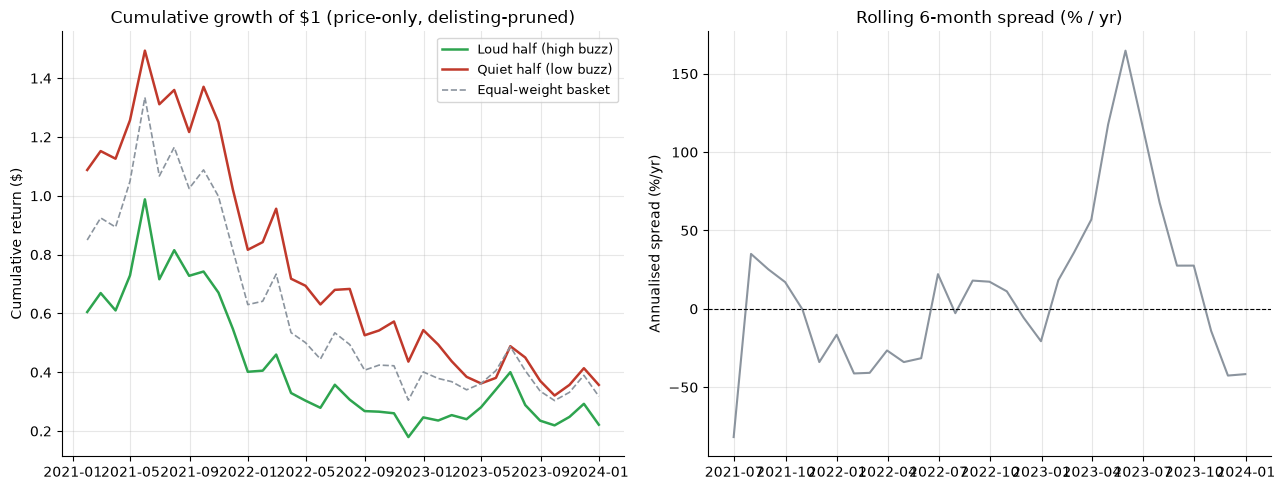

Loud-minus-quiet spread: -3.5%/yr = -29.3 bps/mo   HAC t = -0.14
Hit rate: 47.2%  (a coin flip)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if HAVE_REAL:
    ax = axes[0]
    cum_hype   = (1 + res["hype"].dropna()).cumprod()
    cum_quiet  = (1 + res["quiet"].dropna()).cumprod()
    cum_basket = (1 + res["basket"].dropna()).cumprod()
    ax.plot(cum_hype.index,   cum_hype.values,   color=GREEN, lw=1.8, label="Loud half (high buzz)")
    ax.plot(cum_quiet.index,  cum_quiet.values,  color=RED,   lw=1.8, label="Quiet half (low buzz)")
    ax.plot(cum_basket.index, cum_basket.values, color=GREY,  lw=1.2, ls="--", label="Equal-weight basket")
    ax.set_title("Cumulative growth of $1 (price-only, delisting-pruned)")
    ax.set_ylabel("Cumulative return ($)")
    ax.legend(fontsize=9)

    ax = axes[1]
    roll = spread.rolling(6).mean() * 12 * 100
    ax.plot(roll.index, roll.values, color=GREY, lw=1.5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title("Rolling 6-month spread (% / yr)")
    ax.set_ylabel("Annualised spread (%/yr)")
else:
    for ax in axes:
        ax.text(0.5, 0.5, f"Cache absent\nFrozen: spread = {R['spread_ann']:+.1f}%/yr  t = {R['spread_t']:+.2f}",
                ha="center", va="center", transform=ax.transAxes, fontsize=12, color=GREY)
        ax.set_title("(frozen numbers)")

plt.tight_layout()
plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Loud-minus-quiet spread: {R['spread_ann']:+.1f}%/yr = {R['spread_bps']:+.1f} bps/mo   HAC t = {R['spread_t']:+.2f}")
print(f"Hit rate: {R['spread_hit']:.1%}  (a coin flip)")


## The headline: the buzz tells you nothing

The loud-minus-quiet spread is **-3.5%/yr with a HAC *t* of -0.14** -- a
statistical zero. Three things to notice:

1. **The whole basket bled.** Buying *any* of these names over 2021-2023 lost about
   **-23%/yr**. The loud half (-25.9%/yr) and the quiet half (-22.4%/yr) both
   cratered -- the mention rank just didn't sort the wreckage.

2. **The hit rate is 47%** -- indistinguishable from a coin flip.

3. **Mentions are a lagging shadow of price.** Reddit gets loud *because* a stock
   already ran. A proxy that fires *after* the move can't forecast the next one.


## Why the headline is, if anything, *too kind*

In [5]:
print("Two reasons the real edge is even worse than the (already-zero) headline:")
print()
print("1. SURVIVORSHIP via delisting: WISH/BBBY blew up. When a name has no price")
print("   in a month it silently drops from the short leg -- so the worst collapses")
print("   are quietly excluded, FLATTERING any 'short the hype' result.")
print()
print(f"2. COSTS: meme names are illiquid and pay heavy borrow on the short leg.")
print(f"   At 30 bps one-way the net spread is {R['net_spread_ann']:+.1f}%/yr (t={R['net_spread_t']:+.2f}).")
print()
print(f"Even the *reversal* ('short the loud names') is a zero: {R['reversal_ann']:+.1f}%/yr, t={R['reversal_t']:+.2f}.")


Two reasons the real edge is even worse than the (already-zero) headline:

1. SURVIVORSHIP via delisting: WISH/BBBY blew up. When a name has no price
   in a month it silently drops from the short leg -- so the worst collapses
   are quietly excluded, FLATTERING any 'short the hype' result.

2. COSTS: meme names are illiquid and pay heavy borrow on the short leg.
   At 30 bps one-way the net spread is -4.0%/yr (t=-0.15).

Even the *reversal* ('short the loud names') is a zero: +3.5%/yr, t=+0.14.


## The bottom line for the curious

The WSB mention count is **folklore, not a signal.** On a curated 36-month meme
basket it sorts next-month returns no better than chance (loud-minus-quiet
*t* = -0.14, hit rate 47%), the whole basket lost ~23%/yr regardless of buzz, and
the headline is already an *upper bound* because delisted blow-ups drop out of the
short leg.

This is a **None / Mirage**: no statistical signal, and no tradable edge once you
account for illiquidity, borrow, and the fact that mentions are a *lagging* echo of
the price move they supposedly predict.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*